In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [2]:
# 2. Load Dataset
df = pd.read_csv("Google_Stock_Price.csv")

#open_prices = pd.to_numeric(df['Open'], errors='coerce').dropna().values.reshape(-1, 1)

open_prices = pd.to_numeric(df['Open'], errors='coerce')

open_prices = open_prices.dropna()

open_prices = open_prices.values.reshape(-1, 1)

print(df)

                          Price    Adj Close        Close         High  \
0                        Ticker        GOOGL        GOOGL        GOOGL   
1                          Date          NaN          NaN          NaN   
2     2020-01-02 00:00:00+00:00  68.18682098  68.43399811  68.43399811   
3     2020-01-03 00:00:00+00:00  67.83010101   68.0759964      68.6875   
4     2020-01-06 00:00:00+00:00  69.63805389  69.89050293  69.91600037   
...                         ...          ...          ...          ...   
1255  2024-12-24 00:00:00+00:00  196.1100006  196.1100006  196.1100006   
1256  2024-12-26 00:00:00+00:00  195.6000061  195.6000061       196.75   
1257  2024-12-27 00:00:00+00:00  192.7599945  192.7599945  195.3200073   
1258  2024-12-30 00:00:00+00:00  191.2400055  191.2400055  192.5500031   
1259  2024-12-31 00:00:00+00:00  189.3000031  189.3000031  191.9600067   

              Low         Open    Volume  
0           GOOGL        GOOGL     GOOGL  
1             NaN        

In [3]:
# 3. Feature Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(open_prices)

In [4]:
# 4. Train/Test Split (80/20)
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [5]:
# 5. Create sequences (60 days -> next day)
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data, time_step=60)
X_test, y_test = create_dataset(test_data, time_step=60)

In [6]:
# 6. Reshape to [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [7]:
# 7. Build RNN model (SimpleRNN)
model = Sequential()
model.add(SimpleRNN(50, return_sequences=True, input_shape=(60, 1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

C:\Users\rawat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)        │ (None, 60, 50)        │        2,600 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ simple_rnn_1 (SimpleRNN)      │ (None, 50)            │        5,050 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 1)             │           51 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 8. Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.0216
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0012  
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5.6007e-04  
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 4.7083e-04  
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 4.5162e-04  
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 4.5653e-04 
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 4.1994e-04  
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 4.3162e-04  
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 3.4913e-04  
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 3.6572e-04 
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 3.2299e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 2.9708e-04  
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 2.9969e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 3.0270e-04 
Epoc

In [9]:
# 9. Make predictions
predicted = model.predict(X_test)

# Inverse scaling
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1, 1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step 


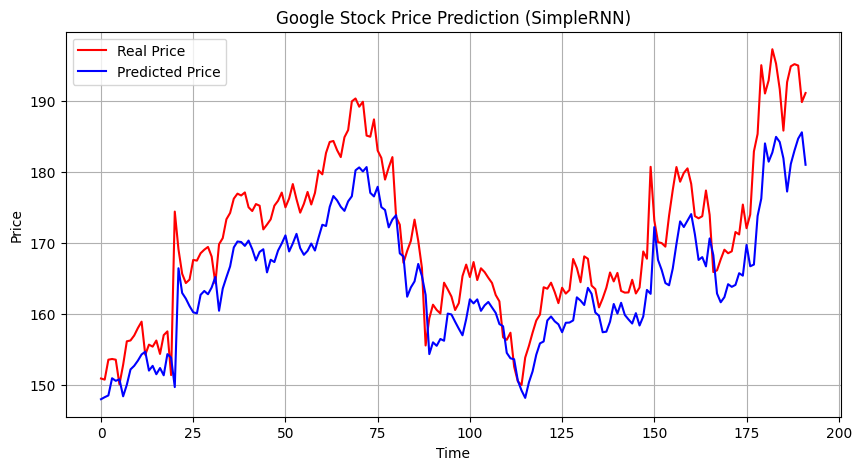

In [10]:
# 10. Plot results
plt.figure(figsize=(10, 5))
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')
plt.title("Google Stock Price Prediction (SimpleRNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()